<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellmender import denoise_count_matrix
# except ImportError:
#     print("cellmender not found, installing...")
#     !pip install -U -q cellmender[analysis]

In [2]:
import os
import anndata as ad
import scanpy as sc
from cellmender import denoise_count_matrix
import cellmender.utils as cm_utils

cellmender_dir = "/data/cellmender"   #!!!! os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellmender"

# Compare CellBender vs. cellmender

Some datasets of use:
- tiny mouse heart dataset from CellBender (CellBender/examples/remove_background/generate_tiny_10x_dataset.py): https://www.10xgenomics.com/resources/datasets/10-k-heart-cells-from-an-e-18-mouse-v-3-chemistry-3-standard-3-0-0 

- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k?

In [37]:
dataset_name = "pbmc8k"  # options: pbmc8k
iterations = 4
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
scar_env = "/home/jrich/miniconda3/envs/scar_gpu"
use_cuda = True
threads = 8

In [4]:
data_dir = os.path.join(cellmender_dir, "notebooks", "data", dataset_name, "idempotency")
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", dataset_name, "idempotency")
os.makedirs(out_dir, exist_ok=True)

adata_path_raw = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
sequencing_technology = "10XV2"
model_pkl = "Immune_All_High.pkl"  # path to celltypist model pkl file
expected_cells = 8381

if not os.path.exists(adata_path_raw):
    !wget -O {adata_path_raw} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5

matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
os.makedirs(matrix_tar_files_dir, exist_ok=True)
raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "GRCh38")
filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "GRCh38")
if not os.path.exists(raw_tar_file_dir):
    raw_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_raw_gene_bc_matrices.tar.gz")
    !wget -O {raw_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices.tar.gz
    !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
if not os.path.exists(filtered_tar_file_dir):
    filtered_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_filtered_gene_bc_matrices.tar.gz")
    !wget -O {filtered_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_filtered_gene_bc_matrices.tar.gz
    !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}

min_genes = 0
min_cells = 0
umi_top_percentile_to_remove = 5
unique_genes_top_percentile_to_remove = 5
mt_gene_percentile_to_remove = 10
max_mt_percentage = None
n_top_genes = 2000
n_pcs = 25
n_neighbors = 20
leiden_resolution = 1.0

## Raw

In [5]:
adata_raw = cm_utils.load_adata(adata_path_raw, verbose=verbose)
adata_raw.var_names_make_unique()

adata_raw = cm_utils.infer_empty_droplets(adata_raw, method="threshold", expected_cells=expected_cells, verbose=verbose)  # adds adata.obs["is_empty"]

15:03:28 - INFO - Loading adata from '/data/cellmender/notebooks/data/pbmc8k/idempotency/pbmc8k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## cellmender

In [ ]:
adata = adata_raw.copy()

adatas_cellmender = [adata]
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    adata_path_cellmender = os.path.join(data_dir, f"cellmender_iteration{it}.h5ad")
    cellmender_log_file = os.path.join(data_dir, f"cellmender_iteration{it}.log")
    if not os.path.exists(adata_path_cellmender) or overwrite:
        if "celltype" not in adata.obs.columns:
            adata = cm_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
        adata = denoise_count_matrix(adata, adata_out=adata_path_cellmender, max_iter=40, beta=0.03, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, cell_ambient_fraction=0.01, threads=threads, verbose=verbose, log_file=cellmender_log_file)
    else:
        adata = ad.read_h5ad(adata_path_cellmender)
    adata_filtered = adata[~adata.obs["is_empty"]].copy()
    adata_filtered.var_names_make_unique()
    adatas_cellmender.append(adata_filtered)

Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4
Iteration 4 / 4


## CellBender (v0.3.0)

In [7]:
adatas_cellbender = [adata_raw]
runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
gpus = "--gpus all" if use_cuda else ""

input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    output_path_local = os.path.join(data_dir, f"cellbender_iteration{it}.h5")
    adata_path_cellbender_filtered = output_path_local.replace(".h5", "_filtered.h5")
    output_path = output_path_local.replace(f"{cellmender_dir}/notebooks/data", "/data")
    if not os.path.exists(output_path_local) or overwrite:
        !docker run --rm {gpus} -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
            cellbender remove-background \
            --input {input_path} \
            --output {output_path} \
            --epochs 150 \
            --fpr 0.01 \
            --model full \
            {runtime}
    input_path = output_path
    adata = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
    adata.var_names_make_unique()
    adatas_cellbender.append(adata)

Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4
Iteration 4 / 4


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## SoupX (v1.6.2)

In [11]:
!echo docker run --rm \
    -w /home/ruser/work \
    -v {cellmender_dir}:{rver_docker_workspace} \
    josephrich98/cellmender_tutorials:soupx.0.1.0 \
    Rscript {rver_docker_workspace}/scripts/run_soupx.R \
        {matrix_tar_files_dir_soupx.replace(cellmender_dir, rver_docker_workspace)} \
        {adata_soupx_obs_csv.replace(cellmender_dir, rver_docker_workspace)} \
        {soupx_out_prefix.replace(cellmender_dir, rver_docker_workspace)} \
        leiden

docker run --rm -w /home/ruser/work -v /data/cellmender:/home/ruser/work/cellmender josephrich98/cellmender_tutorials:soupx.0.1.0 Rscript /home/ruser/work/cellmender/scripts/run_soupx.R /home/ruser/work/cellmender/notebooks/data/pbmc8k/idempotency/soupX_iteration2_matrix_tar_files /home/ruser/work/cellmender/notebooks/data/pbmc8k/idempotency/pbmc8k_soupx_obs.csv /home/ruser/work/cellmender/notebooks/data/pbmc8k/idempotency/soupX_iteration3 leiden


In [32]:
adata_soupx_obs_csv = f"{data_dir}/{dataset_name}_soupx_obs.csv"
if not os.path.exists(adata_soupx_obs_csv) or overwrite:
    adata_soupx_tmp = cm_utils.load_adata(filtered_tar_file_dir)
    adata_soupx_tmp = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_soupx_tmp.obs[["leiden"]].to_csv(adata_soupx_obs_csv)

matrix_tar_files_dir_soupx = matrix_tar_files_dir
# raw_tar_file_dir_soupx = raw_tar_file_dir
# filtered_tar_file_dir_soupx = filtered_tar_file_dir
adatas_soupX = [adata_raw]
adatas_soupX_concat = [adata_raw]
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    soupx_out_prefix = os.path.join(data_dir, f"soupX_iteration{it}")
    if not os.path.exists(f"{soupx_out_prefix}.mtx") or overwrite:
        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:soupx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_soupx.R \
                {matrix_tar_files_dir_soupx.replace(cellmender_dir, rver_docker_workspace)} \
                {adata_soupx_obs_csv.replace(cellmender_dir, rver_docker_workspace)} \
                {soupx_out_prefix.replace(cellmender_dir, rver_docker_workspace)} \
                leiden
        
    adata_soupx = cm_utils.load_adata(soupx_out_prefix)
    adata_soupx.var_names_make_unique()
    adatas_soupX.append(adata_soupx)

    matrix_tar_files_dir_soupx = f"{soupx_out_prefix}_matrix_tar_files"
    # raw_tar_file_dir_soupx = os.path.join(matrix_tar_files_dir_soupx, "raw_gene_bc_matrices", "GRCh38")
    # filtered_tar_file_dir_soupx = os.path.join(matrix_tar_files_dir_soupx, "filtered_gene_bc_matrices", "GRCh38")
    
    # merge adatas_soupX_concat[it-1] into it, and fill NaN with True
    adata_soupx.obs["is_empty"] = False
    adata_prev = adatas_soupX_concat[it-1]
    cells_prev = set(adata_prev.obs_names)  # 1. find missing cells
    cells_curr = set(adata_soupx.obs_names)
    missing_cells = list(cells_prev - cells_curr)
    adata_missing = adata_prev[missing_cells].copy()  # 2. subset missing cells
    adata_missing.obs["is_empty"] = True
    adata_soupx = sc.concat([adata_soupx, adata_missing], join="outer", merge="unique", label=None, index_unique=None)  # 3. concat
    adatas_soupX_concat.append(adata_soupx)
    if not os.path.exists(matrix_tar_files_dir_soupx) or overwrite:
        _ = cm_utils.write_10x_like(adata_soupx, matrix_tar_files_dir_soupx, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="GRCh38", write_raw=True, write_filtered=True)

Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4


2871.22s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Loading data from: /home/ruser/work/cellmender/notebooks/data/pbmc8k/idempotency/soupX_iteration2_matrix_tar_files 
Loading raw count data
Loading cell-only count data
Loading extra analysis data where available
Assigning clusters...
Estimating contamination fraction...
1409 genes passed tf-idf cut-off and 840 soup quantile filter.  Taking the top 100.
Using 1357 independent estimates of rho.
Estimated global rho of 0.01
Adjusting counts...
Expanding counts from 18 clusters to 8381 cells.
Warning message:
Writing output matrices...
In sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w],  :
  'giveCsparse' is deprecated; setting repr="T" for you
NULL
✅ SoupX completed successfully.
Iteration 4 / 4


3016.73s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Loading data from: /home/ruser/work/cellmender/notebooks/data/pbmc8k/idempotency/soupX_iteration3_matrix_tar_files 
Loading raw count data
Loading cell-only count data
Loading extra analysis data where available
Assigning clusters...
Estimating contamination fraction...
1505 genes passed tf-idf cut-off and 913 soup quantile filter.  Taking the top 100.
Using 1375 independent estimates of rho.
Estimated global rho of 0.01
Adjusting counts...
Expanding counts from 18 clusters to 8381 cells.
Warning message:
In sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w],  :
  'giveCsparse' is deprecated; setting repr="T" for you
Writing output matrices...
NULL
✅ SoupX completed successfully.


## DecontX (v1.8.0)

In [ ]:
matrix_tar_files_dir_decontx = matrix_tar_files_dir
raw_tar_file_dir_decontx = raw_tar_file_dir
filtered_tar_file_dir_decontx = filtered_tar_file_dir
adatas_decontx = [adata_raw]
adatas_decontx_concat = [adata_raw]
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    decontx_out_prefix = os.path.join(data_dir, f"decontx_iteration{it}")
    if not os.path.exists(f"{decontx_out_prefix}.mtx") or overwrite:
        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_decontx.R \
                {raw_tar_file_dir_decontx.replace(cellmender_dir, rver_docker_workspace)} \
                {filtered_tar_file_dir_decontx.replace(cellmender_dir, rver_docker_workspace)} \
                {sequencing_technology} \
                {decontx_out_prefix.replace(cellmender_dir, rver_docker_workspace)} \
                --dont_prepend_sample_to_barcodes
        
    adata_decontx = cm_utils.load_adata(decontx_out_prefix)
    adata_decontx.var_names_make_unique()
    adatas_decontx.append(adata_decontx)

    break

    matrix_tar_files_dir_decontx = f"{decontx_out_prefix}_matrix_tar_files"
    raw_tar_file_dir_decontx = os.path.join(matrix_tar_files_dir_decontx, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir_decontx = os.path.join(matrix_tar_files_dir_decontx, "filtered_gene_bc_matrices", "GRCh38")
    
    # merge adatas_decontx_concat[it-1] into it, and fill NaN with True
    adata_decontx.obs["is_empty"] = False
    adata_prev = adatas_decontx_concat[it-1]
    cells_prev = set(adata_prev.obs_names)  # 1. find missing cells
    cells_curr = set(adata_decontx.obs_names)
    missing_cells = list(cells_prev - cells_curr)
    adata_missing = adata_prev[missing_cells].copy()  # 2. subset missing cells
    adata_missing.obs["is_empty"] = True
    adata_decontx = sc.concat([adata_decontx, adata_missing], join="outer", merge="unique", label=None, index_unique=None)  # 3. concat
    adatas_decontx_concat.append(adata_decontx)
    
    if not os.path.exists(matrix_tar_files_dir_decontx) or overwrite:
        _ = cm_utils.write_10x_like(adata_decontx, matrix_tar_files_dir_decontx, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="GRCh38", write_raw=True, write_filtered=True)
    
    break

Iteration 1 / 4


7097.24s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


📦 Starting DecontX pipeline...
Raw matrix dir:  /home/ruser/work/cellmender/notebooks/data/pbmc8k/idempotency/matrix_tar_files/raw_gene_bc_matrices/GRCh38 
Filtered matrix dir:  /home/ruser/work/cellmender/notebooks/data/pbmc8k/idempotency/matrix_tar_files/filtered_gene_bc_matrices/GRCh38 
Sequencing technology:  10XV2 
Importing filtered CellRanger matrix for 10XV2...
Metrics summary file (metrics_summary.csv) not found for sample: GRCh38
Importing raw CellRanger matrix for 10XV2...
Metrics summary file (metrics_summary.csv) not found for sample: GRCh38
Standardizing cell and gene names...
Running decontX denoising...
Fri Nov 21 01:02:44 2025 ..  8381  cells in the background matrix were removed as they were found in  the filtered matrix.
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Fri Nov 21 01:02:45 2025 .. Analyzing all cells
Fri Nov 21 01:02:45 2025 .... Generating UMAP and estimating cell types
Fri Nov 21 

## scAR (v0.7.0)

In [ ]:
%env MPLBACKEND=

matrix_tar_files_dir_scar = matrix_tar_files_dir
raw_tar_file_dir_scar = raw_tar_file_dir
filtered_tar_file_dir_scar = filtered_tar_file_dir
adatas_scar = [adata_raw]
adatas_scar_concat = [adata_raw]
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    scar_out_prefix = os.path.join(data_dir, f"scar_iteration{it}")
    adata_path_scar = os.path.join(data_dir, f"adata_scar_iteration{it}.h5ad")
    if not os.path.exists(f"{adata_path_scar}.mtx") or overwrite:
        runtime = "--cuda" if use_cuda else ""
        conda_run_flag = "-p" if "/" in scar_env else "-n"
        !conda run {conda_run_flag} {scar_env} \
            python {cellmender_dir}/scripts/run_scar.py \
            -r {raw_tar_file_dir_scar} \
            -f {filtered_tar_file_dir_scar} \
            -o {adata_path_scar} \
            {runtime} \
            --epochs 200
        
    adata_scar = cm_utils.load_adata(adata_path_scar)
    adata_scar.var_names_make_unique()
    adatas_scar.append(adata_scar)

    matrix_tar_files_dir_scar = f"{scar_out_prefix}_matrix_tar_files"
    raw_tar_file_dir_scar = os.path.join(matrix_tar_files_dir_scar, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir_scar = os.path.join(matrix_tar_files_dir_scar, "filtered_gene_bc_matrices", "GRCh38")

    # merge adatas_scar_concat[it-1] into it, and fill NaN with True
    adata_scar.obs["is_empty"] = False
    adata_prev = adatas_scar_concat[it-1]
    cells_prev = set(adata_prev.obs_names)  # 1. find missing cells
    cells_curr = set(adata_scar.obs_names)
    missing_cells = list(cells_prev - cells_curr)
    adata_missing = adata_prev[missing_cells].copy()  # 2. subset missing cells
    adata_missing.obs["is_empty"] = True
    adata_scar = sc.concat([adata_scar, adata_missing], join="outer", merge="unique", label=None, index_unique=None)  # 3. concat
    adatas_scar_concat.append(adata_scar)
    
    if not os.path.exists(matrix_tar_files_dir_scar) or overwrite:
        _ = cm_utils.write_10x_like(adata_scar, matrix_tar_files_dir_scar, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="GRCh38", write_raw=True, write_filtered=True)

# Analysis

In [ ]:
adatas_dict = {
    "cellmender": adatas_cellmender,
    "cellbender": adatas_cellbender,
    "soupX": adatas_soupX,
    "decontx": adatas_decontx,
    "scar": adatas_scar
}

tools = ["cellmender", "cellbender", "soupX", "decontx", "scar"]


# # for debugging
# adatas_dict = {"cellmender": adatas_cellmender}
# tools = ["cellmender"]

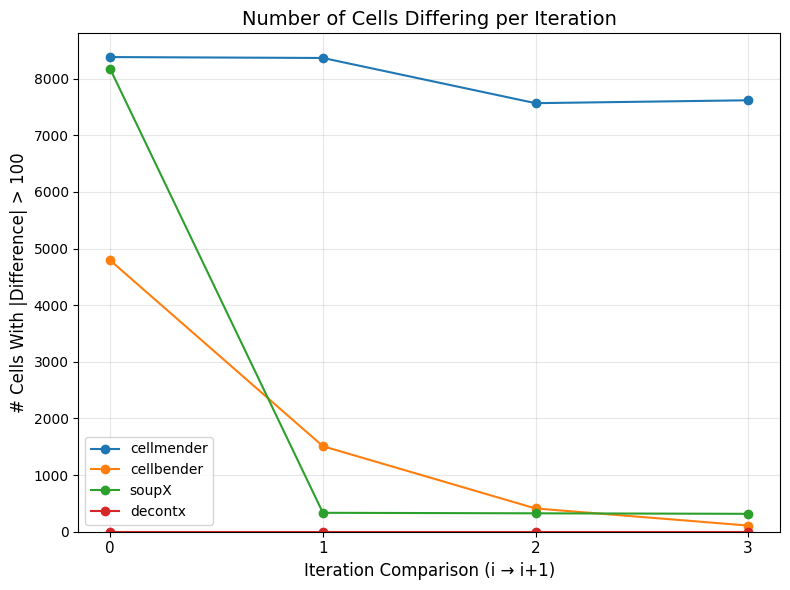

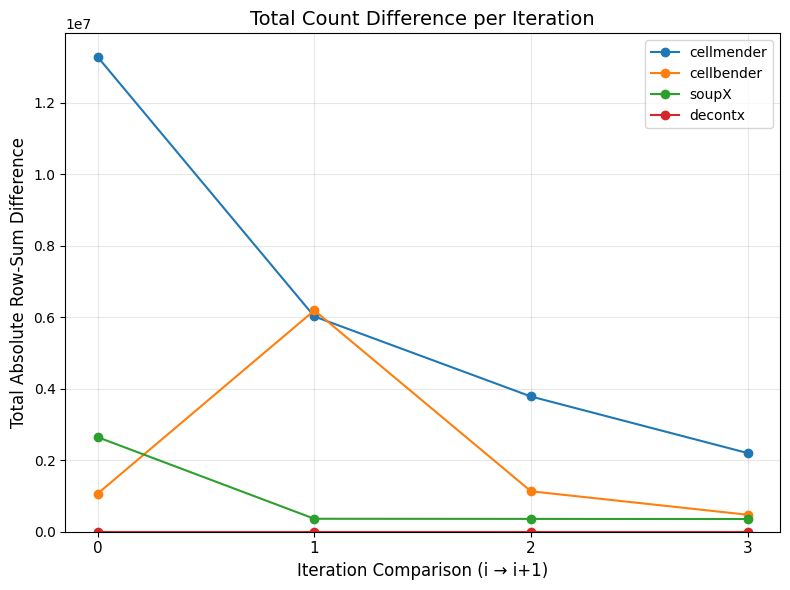

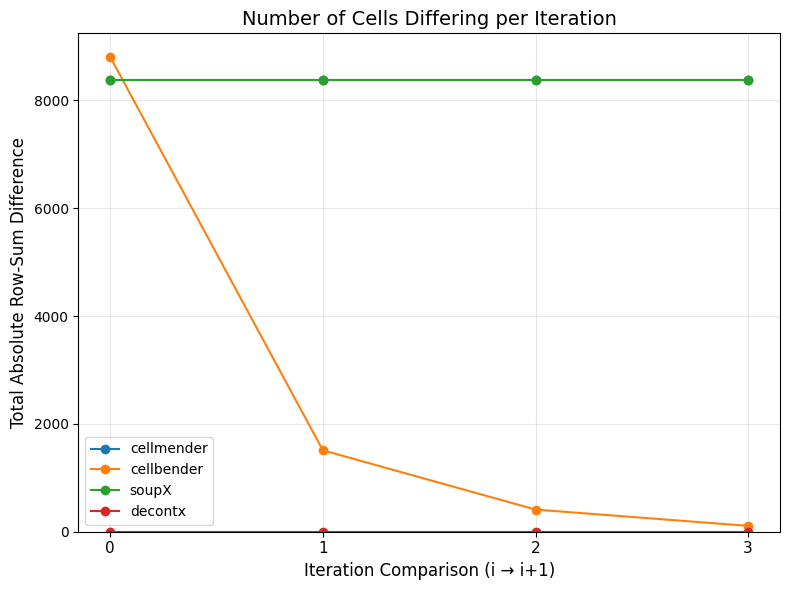

In [41]:
diff_counts = cm_utils.plot_iterative_difference_counts(adatas_dict, metric="cells", threshold=100, title="Number of Cells Differing per Iteration", out_path=os.path.join(out_dir, "diff_cells.png"))
diff_counts = cm_utils.plot_iterative_difference_counts(adatas_dict, metric="counts", title="Total Count Difference per Iteration", out_path=os.path.join(out_dir, "diff_counts.png"))
diff_counts = cm_utils.plot_iterative_difference_counts(adatas_dict, metric="number_of_cells", title="Number of Cells Differing per Iteration", out_path=os.path.join(out_dir, "diff_number_of_cells.png"))

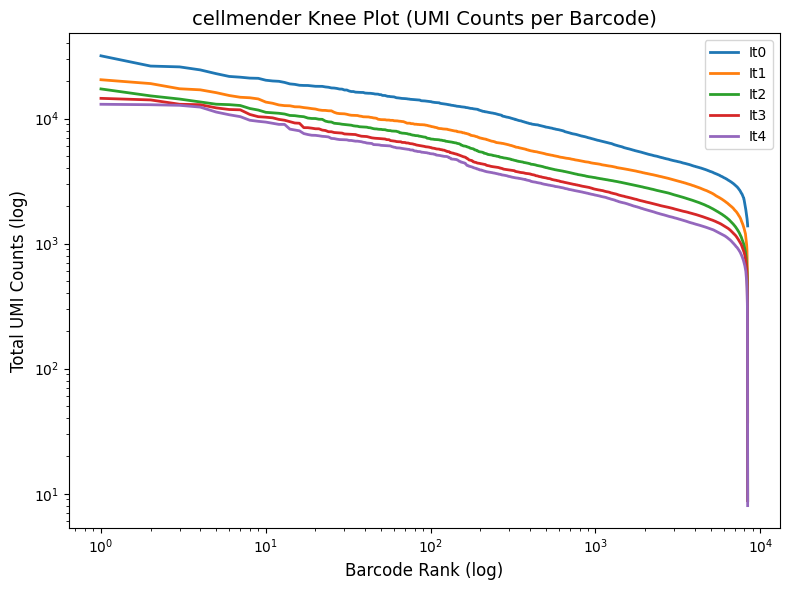

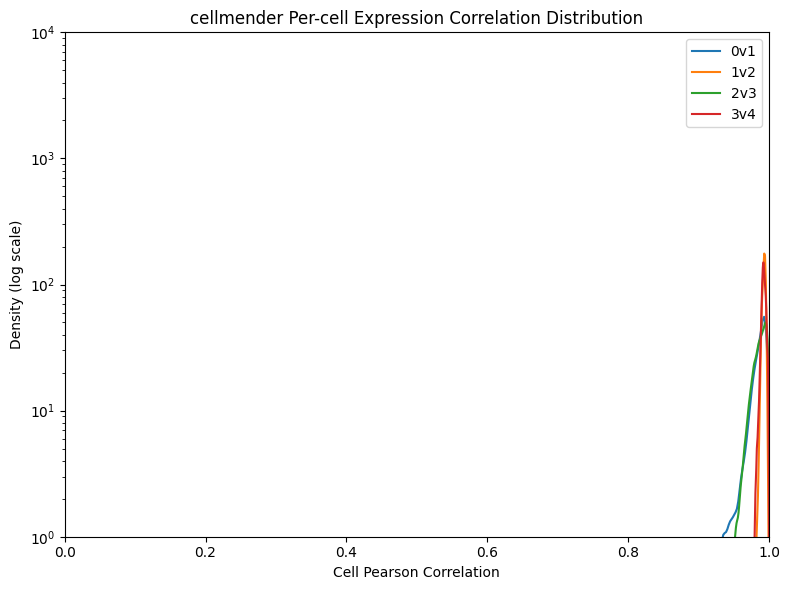

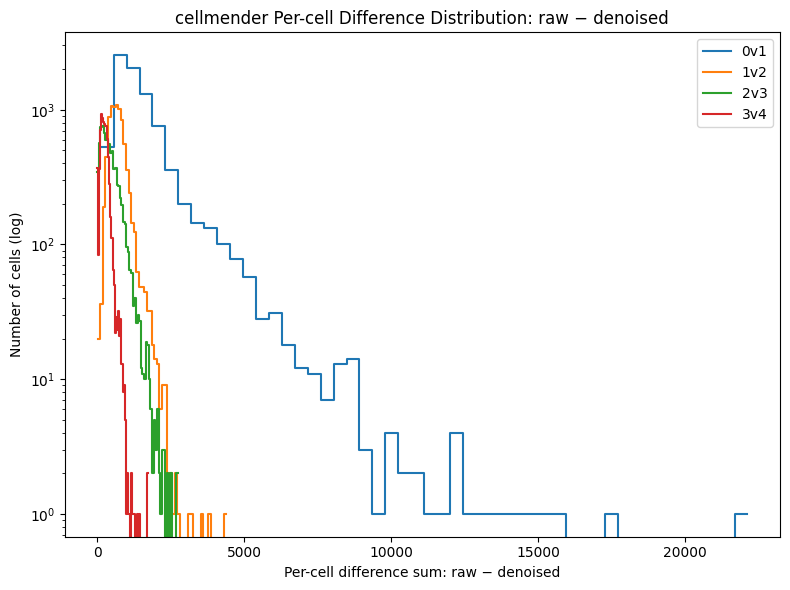

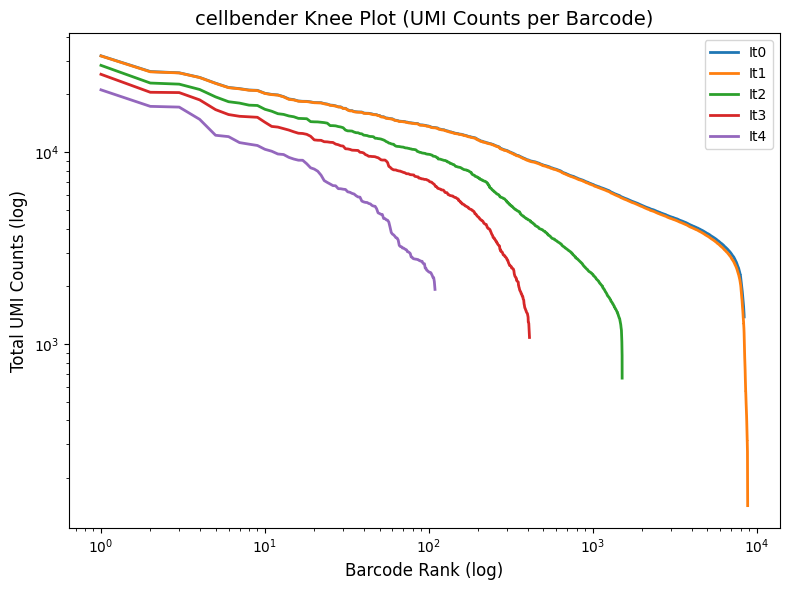

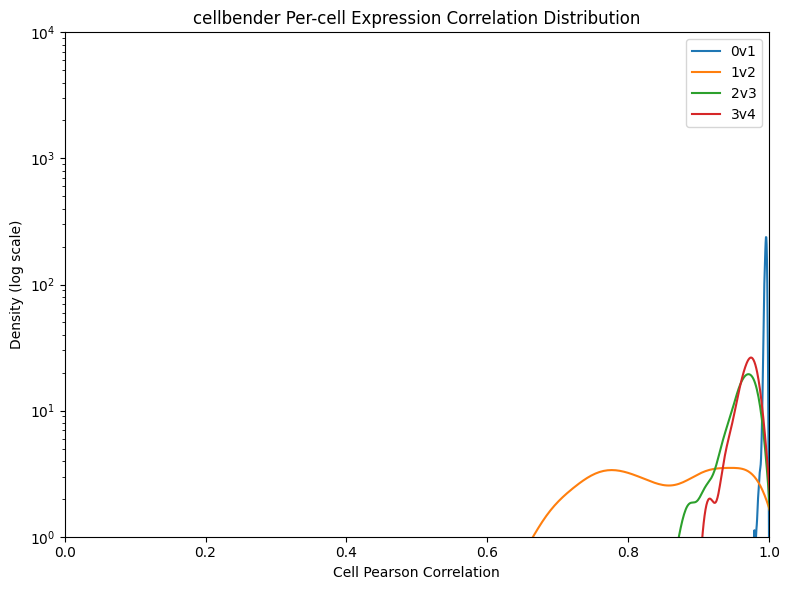

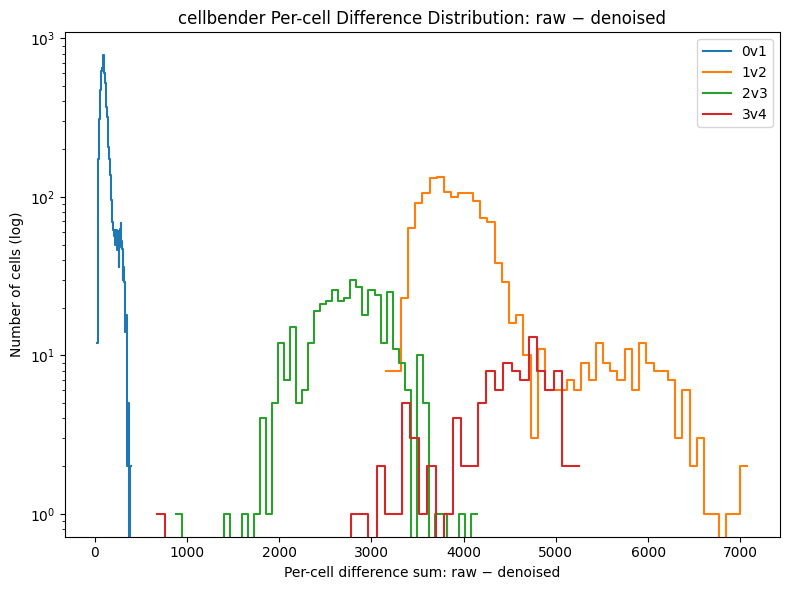

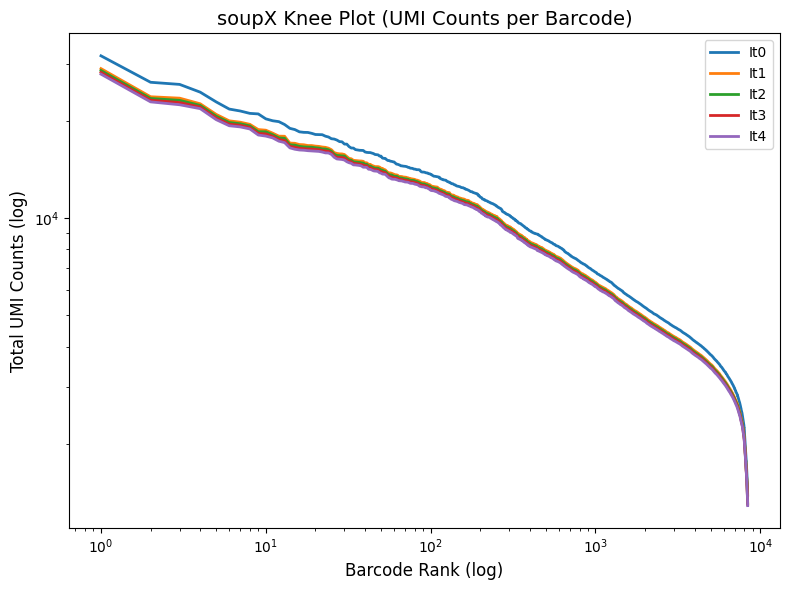

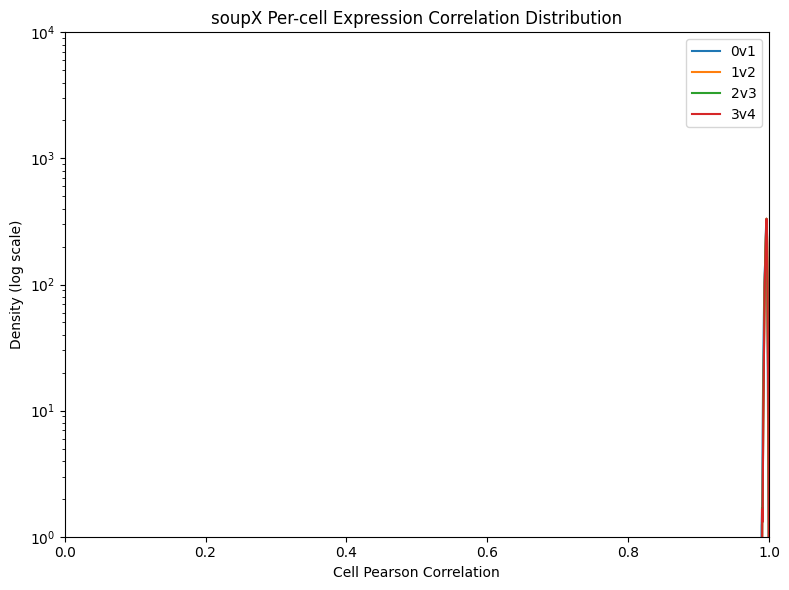

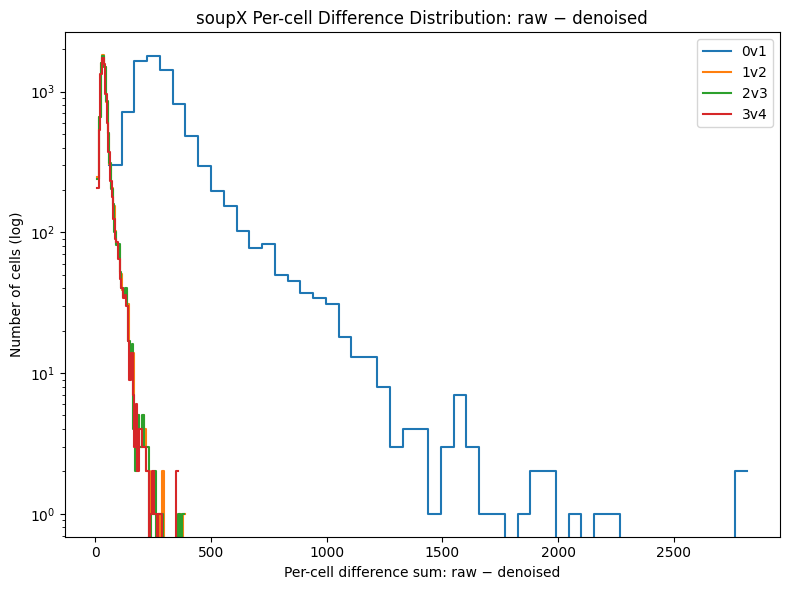

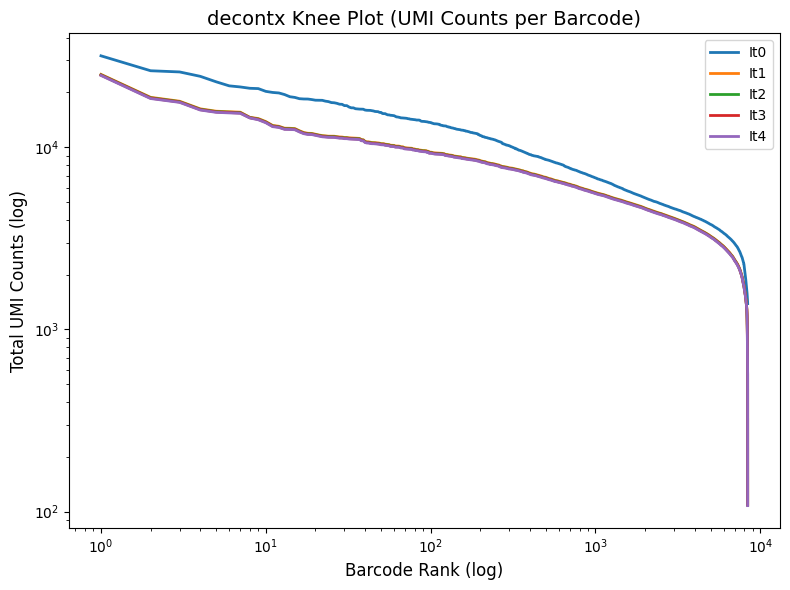

/home/jrich/Desktop/cellmender/cellmender/utils/visualization_utils.py:1028: RuntimeWarning: divide by zero encountered in log10
  y_max = 10 ** np.ceil(np.log10(max_count))
/home/jrich/Desktop/cellmender/cellmender/utils/visualization_utils.py:1046: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


ValueError: math domain error

Error in callback <function _draw_all_if_interactive at 0x7f7c8ea9e320> (for post_execute), with arguments args (),kwargs {}:


ValueError: math domain error

ValueError: math domain error

<Figure size 800x600 with 1 Axes>

In [48]:
labels_knee = [f"It{i}" for i in range(iterations+1)]
labels_histograms = [f"{i}v{i+1}" for i in range(iterations)]
for tool in tools:
    cm_utils.plot_knee_multi(adatas_dict[tool], labels=labels_knee, title=f"{tool} Knee Plot (UMI Counts per Barcode)", filter_empty=True, out_path=os.path.join(out_dir, f"{tool}_knee_plot_overlay.png"))
    cm_utils.plot_per_cell_correlation_multi(adatas_dict[tool][:-1], adatas_dict[tool][1:], labels=labels_histograms, title=f"{tool} Per-cell Expression Correlation Distribution", out_path=os.path.join(out_dir, f"{tool}_per_cell_correlation_overlay.png"))
    cm_utils.plot_per_cell_difference_multi(adata_raw_list=adatas_dict[tool][:-1], adata_denoised_list=adatas_dict[tool][1:], labels=labels_histograms, title=f"{tool} Per-cell Difference Distribution: raw − denoised", out_path=os.path.join(out_dir, f"{tool}_per_cell_absolute_difference_overlay.png"))

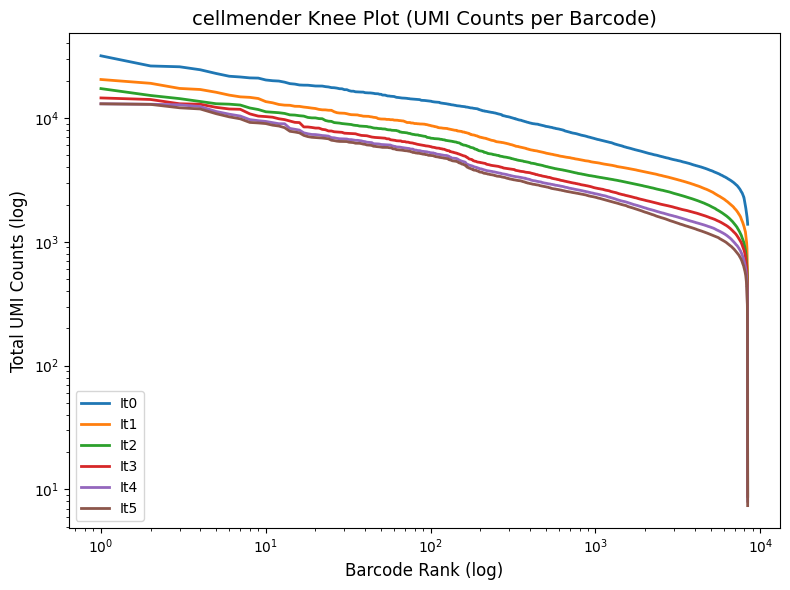

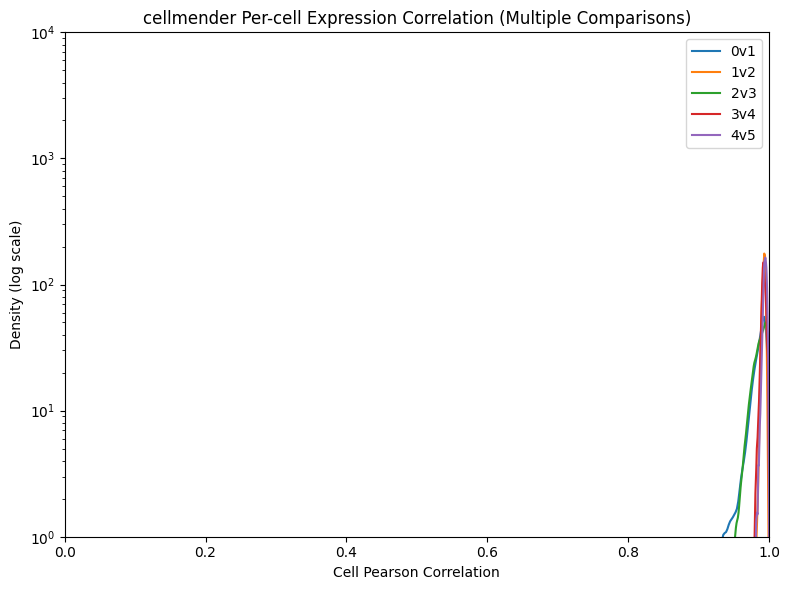

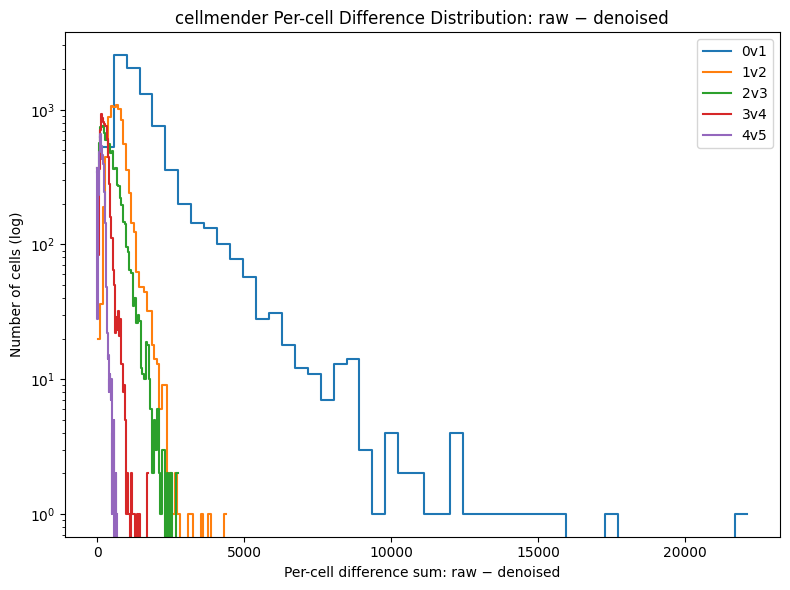

In [ ]:
labels_knee = [f"It{i}" for i in range(iterations+1)]
labels_histograms = [f"{i}v{i+1}" for i in range(iterations)]
for tool in tools:
    cm_utils.plot_knee_multi(adatas_dict[tool], labels=labels_knee, title=f"{tool} Knee Plot (UMI Counts per Barcode)", filter_empty=True, out_path=os.path.join(out_dir, f"{tool}_knee_plot_overlay.png"))
    cm_utils.plot_per_cell_correlation_multi(adatas_dict[tool][:-1], adatas_dict[tool][1:], labels=labels_histograms, title=f"{tool} Per-cell Expression Correlation Distribution", out_path=os.path.join(out_dir, f"{tool}_per_cell_correlation_overlay.png"))
    cm_utils.plot_per_cell_difference_multi(adata_raw_list=adatas_dict[tool][:-1], adata_denoised_list=adatas_dict[tool][1:], labels=labels_histograms, title=f"{tool} Per-cell Difference Distribution: raw − denoised", out_path=os.path.join(out_dir, f"{tool}_per_cell_absolute_difference_overlay.png"))

In [ ]:
# max_points = 10_000
# for i in range(1, iterations+1):
#     for tool in tools:
#         adatas_tool = adatas_dict[tool]
#         if len(adatas_tool) <= i:
#             continue
#         x_name = f"{tool} Iteration {i-1}" if i > 1 else "Raw expression"
#         y_name = f"{tool} Iteration {i}"

#         cm_utils.plot_matrix_scatterplot(adatas_tool[i-1], adatas_tool[i], scale="log", x_axis=x_name, y_axis=y_name, max_points=max_points, out_path=os.path.join(out_dir, f"{tool}_iteration{i}_expression_scatterplot_{max_points}points.png"), show=True)
#         cm_utils.plot_per_cell_correlation(adatas_tool[i-1], adatas_tool[i], title=f"Cell Pearson Correlation Histogram: {tool} Iteration {i}", out_path=os.path.join(out_dir, f"{tool}_iteration{i}_per_cell_correlation.png"))
#         cm_utils.plot_per_cell_difference(adatas_tool[i-1], adatas_tool[i], tool=tool, out_path=os.path.join(out_dir, f"{tool}_iteration{i}_per_cell_absolute_difference.png"))